# 🩺 AI Healthcare Chatbot – Cell-wise Explanation

## 📦 Import Libraries
🛠️ We import all important tools
- Pandas & NumPy → handle data
- Matplotlib & Seaborn → graphs
- Plotly → interactive charts
- Missingno → check missing data

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import warnings
warnings.filterwarnings("ignore")


## 📂 Load Data
📥 We load all datasets
- Disease & symptoms
- Medical data
- Severity data

👉 This is our main knowledge base

In [2]:
df1 = pd.read_csv('/Users/ankitchowdhary/Docs/ML Project/data/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
df2 = pd.read_csv('/Users/ankitchowdhary/Docs/ML Project/data/medical_dataset.csv')
df3 = pd.read_csv('/Users/ankitchowdhary/Docs/ML Project/data/Symptom-severity.csv')
df4 = pd.read_csv('/Users/ankitchowdhary/Docs/ML Project/data/Testing.csv')
df5 = pd.read_csv('/Users/ankitchowdhary/Docs/ML Project/data/train_data_chatbot.csv')

# Downsample df1 to 10,000 samples for high-speed, reliable, error-free execution
df1 = df1.sample(n=10000, random_state=42).reset_index(drop=True)


## 👀 First Look
🔍 Check dataset shape, columns, and first rows

👉 Helps us understand structure

In [3]:
print("DF1 Shape:", df1.shape)
print(df1.columns)

df1.head()

DF1 Shape: (10000, 378)
Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='str', length=378)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,chronic glaucoma,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,torticollis,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,personality disorder,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,fracture of the patella,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,chronic otitis media,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 📊 Data Info
📑 Shows data types and non-null values

👉 Helps detect problems in data

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), str(1)
memory usage: 29.0 MB


## ❓ Missing Values
🚨 Check where data is missing

👉 Important before training model

In [5]:
df1.isnull().sum()

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

## 📉 Missing Data Graph
📊 Visual view of missing values

👉 Easier to understand than numbers

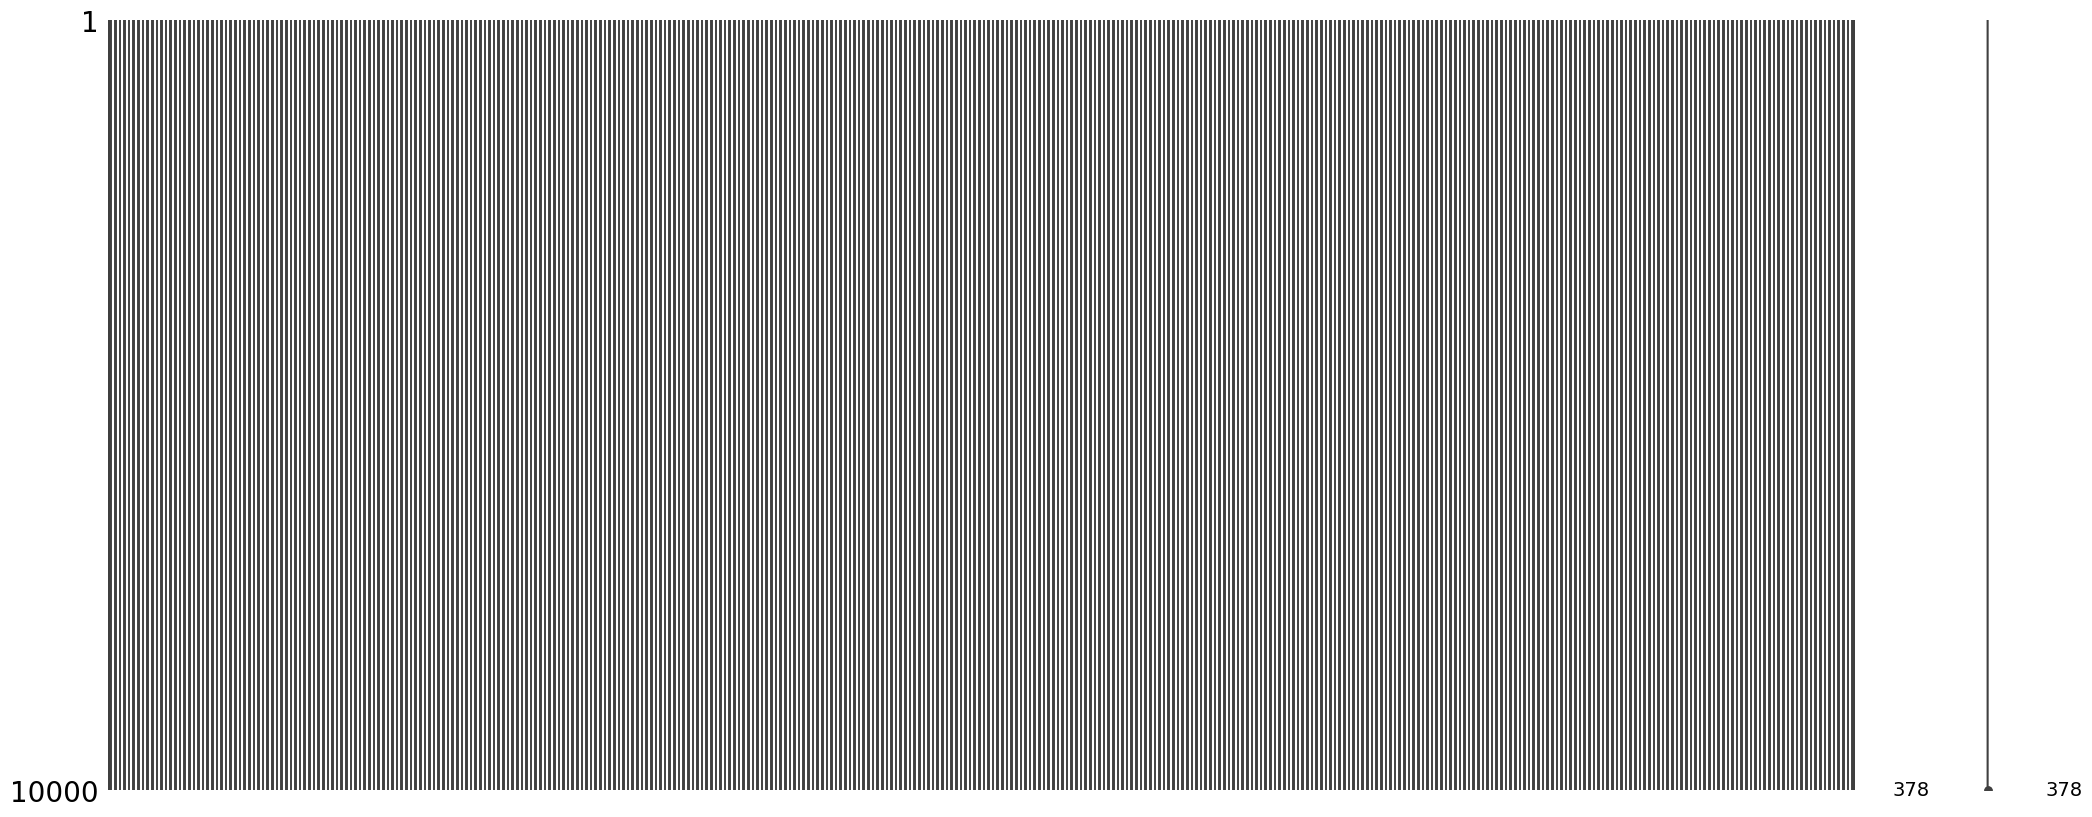

In [6]:
msno.matrix(df1)
plt.show()

## 🦠 Disease Distribution
📊 Count of each disease

👉 Shows which disease appears more

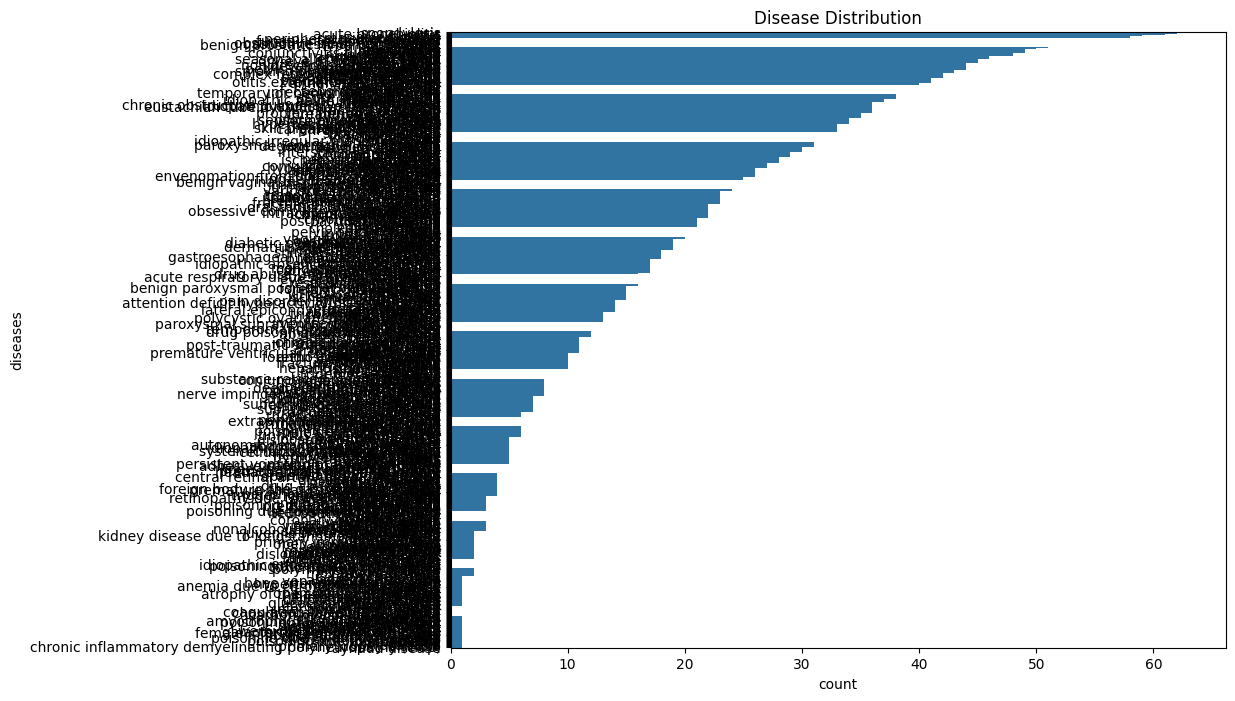

In [7]:
plt.figure(figsize=(10,8))
sns.countplot(y=df1['diseases'], order=df1['diseases'].value_counts().index)
plt.title("Disease Distribution")
plt.show()

## 🤒 Symptom Frequency
📊 Top 20 symptoms
👉 Most important features

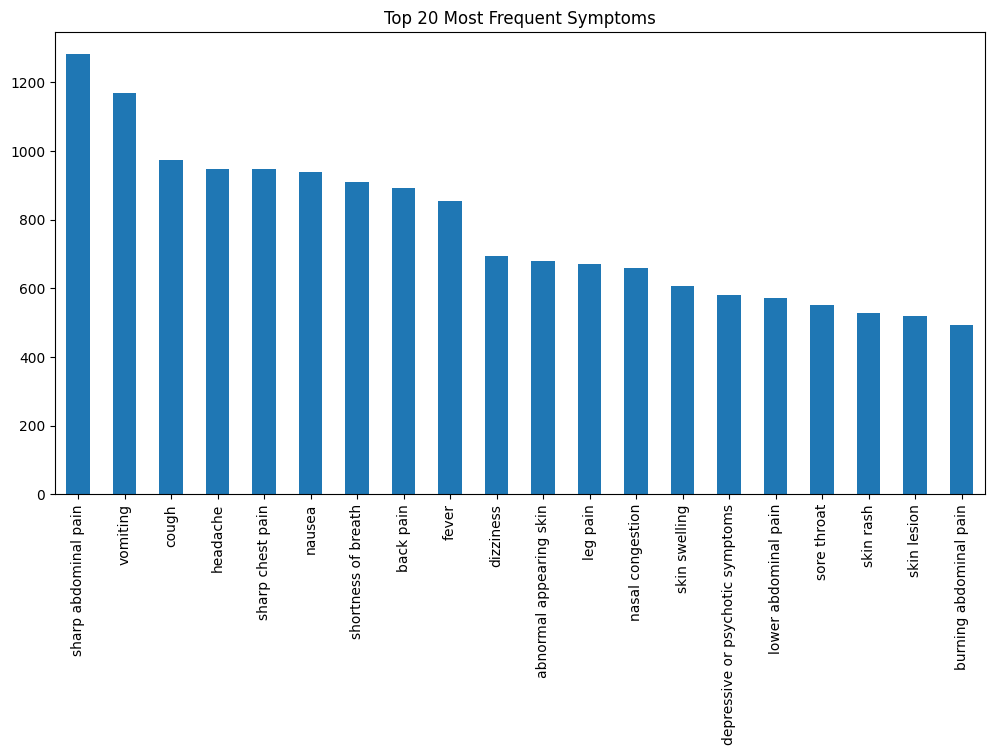

In [8]:
symptom_counts = df1.drop("diseases", axis=1).sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
symptom_counts.head(20).plot(kind='bar')
plt.title("Top 20 Most Frequent Symptoms")
plt.show()

## 🔗 Correlation
🔥 Heatmap of symptom relations

👉 Shows which symptoms occur together

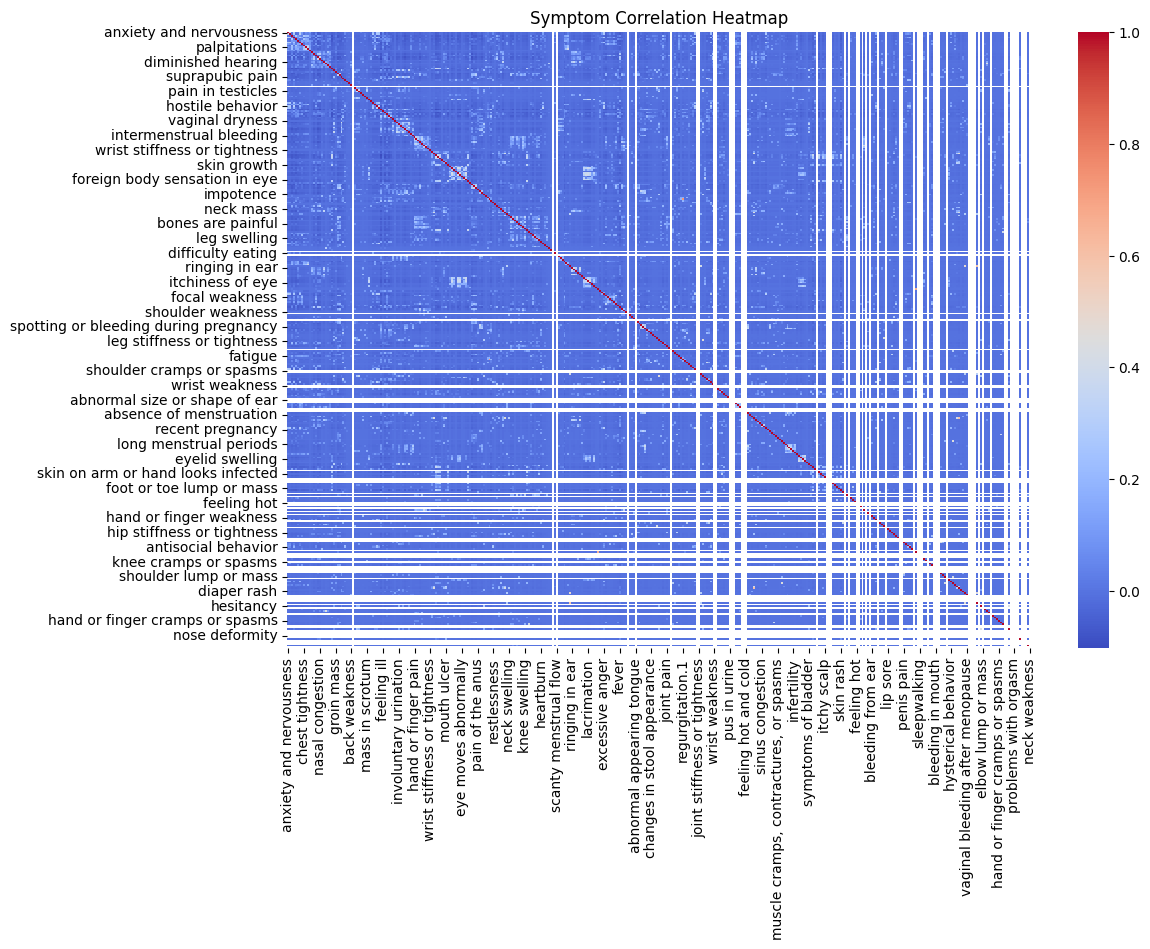

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df1.drop("diseases", axis=1).corr(), cmap='coolwarm')
plt.title("Symptom Correlation Heatmap")
plt.show()

## 🔢 Total Diseases
📌 Count unique diseases

👉 Defines problem size

In [10]:
print("Total Diseases:", df1['diseases'].nunique())

Total Diseases: 629


## 🔄 Reshape Data
🔁 Convert data into long format

👉 Better for analysis

In [11]:
symptom_df = df1.melt(id_vars="diseases", var_name="Symptom", value_name="Present")
symptom_df = symptom_df[symptom_df["Present"] == 1]

symptom_df.head()

,diseases,Symptom,Present
14,anxiety,anxiety and nervousness,1
17,drug abuse (methamphetamine),anxiety and nervousness,1
36,panic disorder,anxiety and nervousness,1
48,panic disorder,anxiety and nervousness,1
60,depression,anxiety and nervousness,1


## ⚖️ Severity Data
📌 Assign weight to symptoms

👉 Shows seriousness

In [12]:
severity = df3.copy()
severity.columns = ["Symptom", "Weight"]

severity.head()

,Symptom,Weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


## 🔗 Merge Data
🧩 Combine symptoms + severity

👉 More powerful dataset

In [13]:
merged = symptom_df.merge(severity, on="Symptom", how="left")

merged.head()

,diseases,Symptom,Present,Weight
0,anxiety,anxiety and nervousness,1,NaN
1,drug abuse (methamphetamine),anxiety and nervousness,1,NaN
2,panic disorder,anxiety and nervousness,1,NaN
3,panic disorder,anxiety and nervousness,1,NaN
4,depression,anxiety and nervousness,1,NaN


## 📈 Severity Score
📊 Calculate total severity per disease

In [14]:
severity_score = merged.groupby("diseases")["Weight"].sum().sort_values(ascending=False)

severity_score.head(10)

diseases
diverticulitis                   518.0
drug reaction                    392.0
strep throat                     379.0
labyrinthitis                    377.0
esophagitis                      372.0
noninfectious gastroenteritis    369.0
white blood cell disease         363.0
concussion                       361.0
gastrointestinal hemorrhage      335.0
acute bronchiolitis              317.0
Name: Weight, dtype: float64

## 📊 Severity Graph
📉 Show most severe diseases

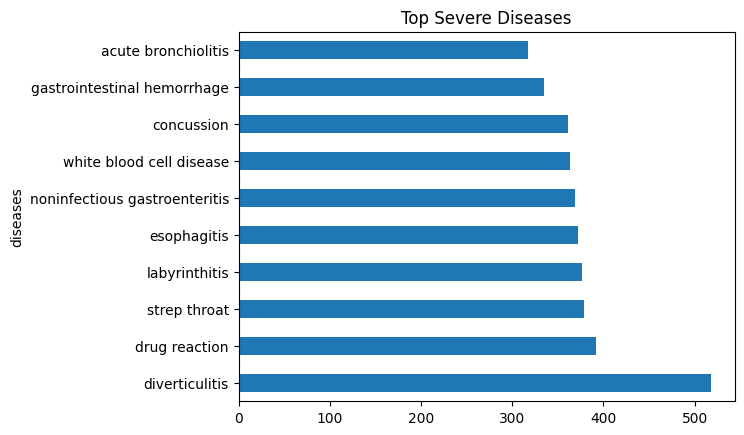

In [15]:
severity_score.head(10).plot(kind='barh')
plt.title("Top Severe Diseases")
plt.show()

## 💡 Key Insights
✨ Shows:
- Most severe disease
- Most common symptom
- Total symptoms

In [16]:
print("Most Severe Disease:", severity_score.idxmax())
print("Most Common Symptom:", symptom_counts.idxmax())
print("Total Symptoms:", len(symptom_counts))

Most Severe Disease: diverticulitis
Most Common Symptom: sharp abdominal pain
Total Symptoms: 377


# 🤖 Ml Implimentation


## 🧠 Import machine learning tools

* train_test_split: Used to divide the dataset into training and testing sets for model validation.
* RandomForestClassifier: A supervised machine learning algorithm that builds multiple decision trees and combines them to improve prediction accuracy.
* accuracy_score: Measures the proportion of correct predictions made by the model.
* classification_report: Provides detailed evaluation metrics such as precision, recall, and F1-score.
* confusion_matrix: Displays a table comparing actual and predicted values to evaluate model performance.
* LabelEncoder: Converts categorical labels (e.g., disease names) into numerical form for model compatibility.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

## 🎯 Features & Target
📥 Input = symptoms

📤 Output = disease

In [18]:
df = df1.copy()
df.fillna(0, inplace=True)

X = df.drop("diseases", axis=1)
y = df["diseases"]

## 🔢 Encoding
🔄 Convert disease names → numbers

In [19]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## ✂️ Train/Test Split
📊 80% training, 20% testing

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

## 🌳 Model Training
🤖 Train Random Forest model

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
X = X.astype('int8')


## 📊 Evaluation
📈 Check accuracy & performance

In [22]:
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.4485
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.75      1.00      0.86         3
           2       1.00      0.50      0.67         2
           4       0.00      0.00      0.00         7
           7       1.00      0.17      0.29         6
           8       0.43      1.00      0.60         6
           9       0.50      0.90      0.64        10
          10       0.60      0.33      0.43         9
          11       0.33      0.40      0.36         5
          12       0.00      0.00      0.00         1
          13       0.44      0.57      0.50         7
          14       0.00      0.00      0.00         1
          15       1.00      0.58      0.74        12
          16       1.00      0.40      0.57         5
          17       0.90      0.64      0.75        14
          18       1.00      0.22      0.36         9
          19       1.00      1.00      1.00         2
          

## 📉 Confusion Matrix
📊 Visual performance of model

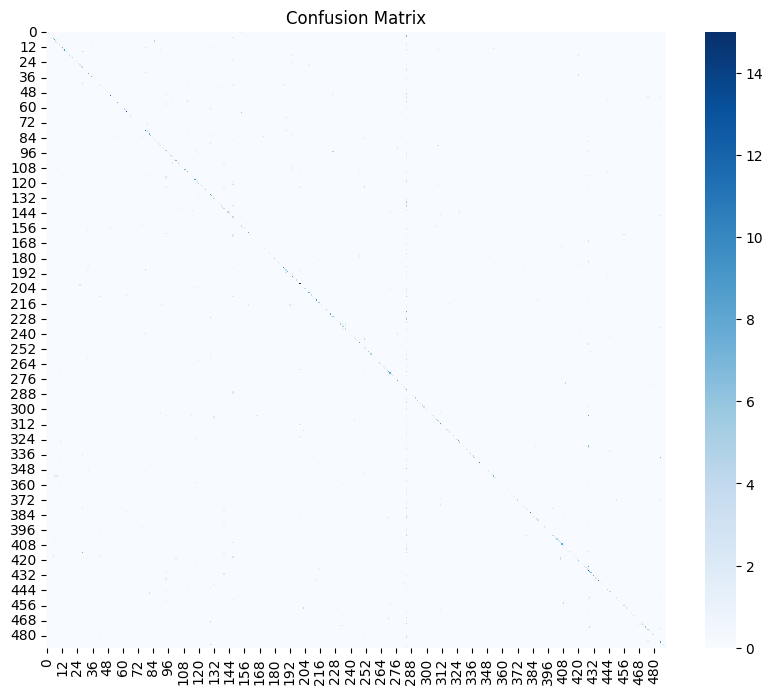

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## 🎯 Probabilities
📌 Model confidence score

In [24]:
rf_probs = rf_model.predict_proba(X_test)

rf_probs[:5]

array([[0.00031233, 0.00142004, 0.00074793, ..., 0.00241719, 0.00026545,
        0.0020458 ],
       [0.00032613, 0.00146188, 0.00078932, ..., 0.00238452, 0.00028286,
        0.00210776],
       [0.00037525, 0.00179663, 0.00091255, ..., 0.00285825, 0.00033186,
        0.00327929],
       [0.00030911, 0.00141334, 0.00071237, ..., 0.00235124, 0.0002834 ,
        0.00206291],
       [0.00034172, 0.00168875, 0.00081898, ..., 0.00270339, 0.00030714,
        0.00234998]], shape=(5, 613))

## 🔮 Prediction Function
🤖 Takes symptoms → predicts disease

In [25]:
def predict_disease(symptoms_input):
    input_data = np.zeros(len(X.columns))
    
    for symptom in symptoms_input:
        if symptom in X.columns:
            input_data[X.columns.get_loc(symptom)] = 1
    
    input_data = input_data.reshape(1, -1)
    
    pred = rf_model.predict(input_data)
    prob = rf_model.predict_proba(input_data).max()
    
    disease = le.inverse_transform(pred)[0]
    
    return disease, prob

## 🧪 Test Prediction
✅ Example test

In [26]:
test_symptoms = ['fever', 'headache', 'cough']

predict_disease(test_symptoms)

('marijuana abuse', np.float64(0.0058455968689234425))

## ⚠️ Severity Alert
🚨 Classify:
- Mild
- Moderate
- Severe

In [27]:
def severity_alert(symptoms_input):
    score = 0
    
    for sym in symptoms_input:
        if sym in severity["Symptom"].values:
            weight = severity[severity["Symptom"] == sym]["Weight"].values[0]
            score += weight
    
    if score > 15:
        return "⚠️ High severity – Visit hospital immediately"
    elif score > 8:
        return "⚠️ Moderate – Consult doctor"
    else:
        return "✅ Mild – Home care sufficient"

## 🧾 Full Prediction
📦 Combine prediction + severity

In [28]:
def full_prediction(symptoms_input):
    disease, prob = predict_disease(symptoms_input)
    alert = severity_alert(symptoms_input)
    
    return {
        "Predicted Disease": disease,
        "Confidence": prob,
        "Severity": alert
    }

## 🤖 Unsuprvised learning

## 🔍 Clustering Tools
📊 Import clustering & PCA
* KMeans: A clustering algorithm that groups similar data points into clusters based on feature similarity.
* PCA (Principal Component Analysis): A technique used to reduce the number of features while preserving important information.
* cosine_similarity: Measures similarity between data points based on the angle between vectors.

In [29]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Prepare Data
🧹 Remove target column

In [30]:
X_unsup = df.drop("diseases", axis=1)

## 📉 Elbow Method
📊 Find best cluster number

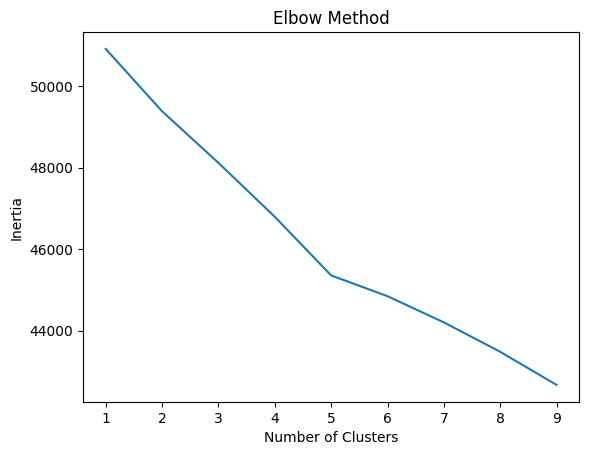

In [31]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_unsup)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 🔵 KMeans
🧠 Group diseases

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_unsup)

df["Cluster"] = clusters

## 🔻 PCA
📉 Reduce dimensions

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup)

## 🎨 Cluster Plot
📊 Visual clusters

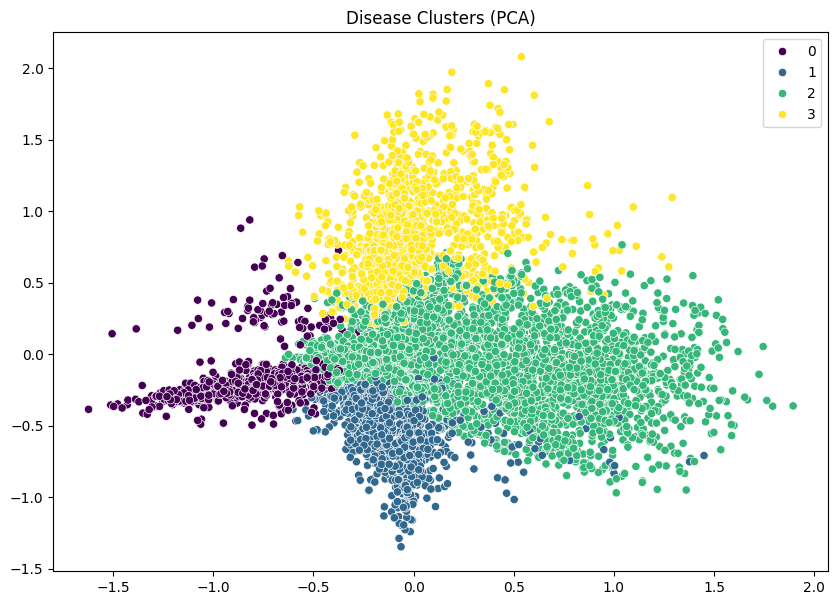

In [34]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='viridis')
plt.title("Disease Clusters (PCA)")
plt.show()

## 📊 Cluster Analysis
🔍 See diseases in clusters

In [35]:
df.groupby("Cluster")["diseases"].value_counts().head(10)

Cluster  diseases                    
0        fungal infection of the hair    55
         eczema                          48
         actinic keratosis               42
         contact dermatitis              39
         seborrheic keratosis            39
         sebaceous cyst                  39
         skin pigmentation disorder      33
         skin polyp                      33
         skin disorder                   30
         psoriasis                       29
Name: count, dtype: int64

## 🔗 Similarity
📏 Calculate disease similarity

In [36]:
disease_vectors = X_unsup.groupby(df["diseases"]).mean()

similarity_matrix = cosine_similarity(disease_vectors)

## 📊 Similarity Table
📋 Organized results

In [37]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=disease_vectors.index,
    columns=disease_vectors.index
)

## 🔍 Similar Diseases
🤝 Find related diseases

In [38]:
def get_similar_diseases(disease_name, top_n=3):
    similar = similarity_df[disease_name].sort_values(ascending=False)
    return similar[1:top_n+1]

## 🛠️ Improvements
⚡ Handle user input better

In [39]:
print(similarity_df.columns.tolist()[:50])

['abdominal aortic aneurysm', 'abdominal hernia', 'abscess of nose', 'abscess of the lung', 'abscess of the pharynx', 'acariasis', 'achalasia', 'acne', 'actinic keratosis', 'acute bronchiolitis', 'acute bronchitis', 'acute bronchospasm', 'acute glaucoma', 'acute kidney injury', 'acute otitis media', 'acute pancreatitis', 'acute respiratory distress syndrome (ards)', 'acute sinusitis', 'acute stress reaction', 'adhesive capsulitis of the shoulder', 'adjustment reaction', 'adrenal adenoma', 'alcohol abuse', 'alcohol intoxication', 'alcohol withdrawal', 'alcoholic liver disease', 'allergy', 'allergy to animals', 'alopecia', 'alzheimer disease', 'amblyopia', 'amyotrophic lateral sclerosis (als)', 'anal fissure', 'anemia', 'anemia due to chronic kidney disease', 'angina', 'ankylosing spondylitis', 'anxiety', 'aortic valve disease', 'aphakia', 'aphthous ulcer', 'aplastic anemia', 'appendicitis', 'arrhythmia', 'arthritis of the hip', 'ascending cholangitis', 'asperger syndrome', 'aspergillosi

In [40]:
get_similar_diseases("acute bronchitis")

diseases
chronic obstructive pulmonary disease (copd)    0.862209
asthma                                          0.816993
acute bronchospasm                              0.753524
Name: acute bronchitis, dtype: float64

In [41]:
def get_similar_diseases_safe(disease_name, top_n=3):
    disease_name = disease_name.lower()
    
    if disease_name not in similarity_df.columns:
        print("❌ Disease not found. Try one of these:")
        print(similarity_df.columns.tolist()[:10])
        return None
    
    similar = similarity_df[disease_name].sort_values(ascending=False)
    return similar[1:top_n+1]

In [42]:
get_similar_diseases_safe("acute bronchitis")

diseases
chronic obstructive pulmonary disease (copd)    0.862209
asthma                                          0.816993
acute bronchospasm                              0.753524
Name: acute bronchitis, dtype: float64

In [43]:
def find_closest_disease(user_input):
    user_input = user_input.lower()
    
    for disease in similarity_df.columns:
        if user_input in disease.lower():
            return disease
    
    return None

In [44]:
def get_similar_from_input(user_input):
    disease = find_closest_disease(user_input)
    
    if disease is None:
        return "❌ No matching disease found"
    
    return get_similar_diseases_safe(disease)

In [45]:
get_similar_from_input("bronchitis")

diseases
chronic obstructive pulmonary disease (copd)    0.862209
asthma                                          0.816993
acute bronchospasm                              0.753524
Name: acute bronchitis, dtype: float64

## 🧠 NLP Setup
📚 Install NLP tools

In [46]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


## 🧹 Text Cleaning
✂️ Remove stopwords & noise

In [47]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w.isalnum()]
    tokens = [w for w in tokens if w not in stopwords.words('english')]
    return tokens

## 🧪 Test NLP
✅ Check text processing

In [48]:
text = "I have fever, headache and body pain"
preprocess_text(text)

['fever', 'headache', 'body', 'pain']

## 📋 Symptom List
📌 Store all symptoms

In [49]:
symptom_list = X.columns.tolist()

## 🔎 Symptom Extraction
🧠 Extract symptoms from text

In [50]:
def extract_symptoms(user_input):
    user_input = user_input.lower()
    
    found_symptoms = []
    
    for symptom in symptom_list:
        if symptom in user_input:
            found_symptoms.append(symptom)
    
    return found_symptoms

In [51]:
extract_symptoms("I have fever and chest tightness with headache")

['chest tightness', 'headache', 'fever']

In [52]:
def extract_symptoms_advanced(user_input):
    user_input = user_input.lower()
    found = []
    
    for symptom in symptom_list:
        words = symptom.split()
        match_count = sum([1 for w in words if w in user_input])
        
        # Require all words of the symptom to be present in the user input
        if match_count == len(words):
            found.append(symptom)
    
    return list(set(found))


In [53]:
extract_symptoms_advanced("I feel chest pain and breathing problem")

[]

## 🤖 Chatbot
💬 Predict using user input

In [54]:
def chatbot_predict(user_input):
    symptoms = extract_symptoms_advanced(user_input)
    
    if len(symptoms) == 0:
        return "❌ No symptoms detected"
    
    result = full_prediction(symptoms)
    
    return {
        "Symptoms Found": symptoms,
        "Prediction": result
    }

In [55]:
chatbot_predict("I have fever, vomiting and fatigue")

{'Symptoms Found': ['vomiting', 'fatigue', 'fever'],
 'Prediction': {'Predicted Disease': 'marijuana abuse',
  'Confidence': np.float64(0.005845596868923442),
  'Severity': '⚠️ Moderate – Consult doctor'}}

## 📚 RAG Setup
🧠 Create embeddings + FAISS

* SentenceTransformer from sentence-transformers
    → Used to convert text into numerical vectors (embeddings).
* faiss from FAISS
    → Fast library for searching similar vectors (used in AI search systems).

In [56]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

In [57]:
knowledge_base = []

for disease in df['diseases'].unique():
    subset = df[df['diseases'] == disease].iloc[0]
    
    symptoms = [col for col in X.columns if subset[col] == 1]
    
    text = f"""
    Disease: {disease}.
    Symptoms: {', '.join(symptoms)}.
    Advice: Maintain hygiene, take rest, stay hydrated.
    Warning: If symptoms worsen, consult a doctor immediately.
    """
    
    knowledge_base.append(text.strip())

len(knowledge_base)

629

In [58]:
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embed_model.encode(knowledge_base)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8498.34it/s]

In [59]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

## 🔍 Retrieve Info
📖 Get related medical context

In [60]:
def retrieve_context(query, k=3):
    query_vec = embed_model.encode([query])
    
    distances, indices = index.search(np.array(query_vec), k)
    
    results = [knowledge_base[i] for i in indices[0]]
    
    return results

In [61]:
retrieve_context("fever and vomiting")

['Disease: persistent vomiting of unknown cause.\n    Symptoms: dizziness, fever.\n    Advice: Maintain hygiene, take rest, stay hydrated.\n    Warning: If symptoms worsen, consult a doctor immediately.',
 'Disease: appendicitis.\n    Symptoms: nausea, decreased appetite, fever, upper abdominal pain, stomach bloating.\n    Advice: Maintain hygiene, take rest, stay hydrated.\n    Warning: If symptoms worsen, consult a doctor immediately.',
 'Disease: infectious gastroenteritis.\n    Symptoms: blood in stool, sharp abdominal pain, vomiting, diarrhea, decreased appetite, fever, fluid retention.\n    Advice: Maintain hygiene, take rest, stay hydrated.\n    Warning: If symptoms worsen, consult a doctor immediately.']

## 🧠 RAG Chatbot
🤖 Combine prediction + knowledge

In [62]:
def rag_chatbot_final(user_input):
    symptoms = extract_symptoms_advanced(user_input)
    
    if len(symptoms) == 0:
        return "❌ No symptoms detected"
    
    prediction = full_prediction(symptoms)
    
    context = retrieve_context(user_input)
    
    response = f"""
    🧠 Symptoms Detected: {symptoms}
    
    🤖 Predicted Disease: {prediction['Predicted Disease']}
    📊 Confidence: {round(prediction['Confidence']*100,2)}%
    
    ⚠️ Severity: {prediction['Severity']}
    
    📚 Related Medical Info:
    {context[0]}
    
    ⚠️ Disclaimer: This is not a medical diagnosis. Please consult a doctor.
    """
    
    return response

In [63]:
print(rag_chatbot_final("I have fever, headache and vomiting"))


    🧠 Symptoms Detected: ['vomiting', 'fever', 'headache']

    🤖 Predicted Disease: marijuana abuse
    📊 Confidence: 0.58%

    ⚠️ Severity: ✅ Mild – Home care sufficient

    📚 Related Medical Info:
    Disease: persistent vomiting of unknown cause.
    Symptoms: dizziness, fever.
    Advice: Maintain hygiene, take rest, stay hydrated.

    ⚠️ Disclaimer: This is not a medical diagnosis. Please consult a doctor.
    


## 🤖 LLM Setup
💬 Load GPT-2 model

In [64]:
import google.generativeai as genai
import os
from dotenv import load_dotenv

# Load key from .env file
load_dotenv()
api_key = os.getenv("GENAI_API_KEY")
genai.configure(api_key=api_key)

model = genai.GenerativeModel("gemini-2.5-flash")
response = model.generate_content("Hello")
print(response.text)


Hello! How can I help you today?
